# Competitive-binding Kd models

This notebook demonstrates competitive-binding models: `comp_3st_specific`, `comp_3st_total`, `comp_4st_specific`, and `comp_4st_total`.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bindcurve as bc

rng = np.random.default_rng(123)

## Helper for synthetic competition data

In [16]:
data_all = bc.DoseResponseData.from_csv(
    "tutorial_data/synthetic/competitive_binding_wide.csv", 
    format="wide",
)

## Three-state specific competition

In [ ]:
params_3st = {
    'ymin': 5.0, 'ymax': 95.0,
    'RT': 0.05, 'LsT': 0.005, 'Kds': 0.02,
    'Kd': 1.6,
}
data_3st = bc.DoseResponseData(
    data_all.table[data_all.table['compound_id'] == 'cmpd_1'],
)
results_3st = bc.fit(
    data_3st,
    model='comp_3st_specific',
    fixed={'ymin': 5.0, 'ymax': 95.0, 'RT': 0.05, 'LsT': 0.005, 'Kds': 0.02},
)
results_3st.summary()

,compound_id,parameter,N_exp,mean,sd,sem,summary_scale,geometric_mean,log10_mean,log10_sd
0,cmpd_1,Kd,3,0.001977,6.849025e-04,3.954287e-04,log10,0.001883,-2.725208,0.173561
1,cmpd_1,Kds,3,0.020000,0.000000e+00,0.000000e+00,log10,0.020000,-1.698970,0.000000
2,cmpd_1,LsT,3,0.005000,0.000000e+00,0.000000e+00,log10,0.005000,-2.301030,0.000000
3,cmpd_1,RT,3,0.050000,8.498375e-18,4.906539e-18,log10,0.050000,-1.301030,0.000000
4,cmpd_1,ymax,3,95.000000,0.000000e+00,0.000000e+00,linear,NaN,NaN,NaN
5,cmpd_1,ymin,3,5.000000,0.000000e+00,0.000000e+00,linear,NaN,NaN,NaN


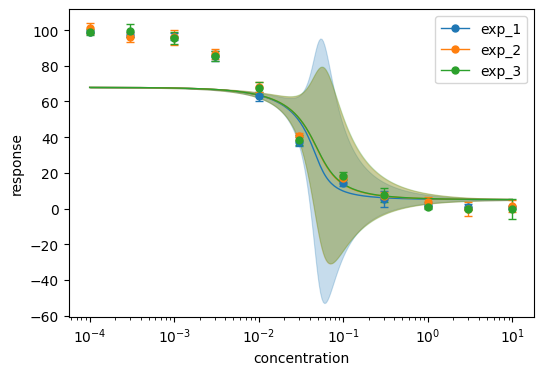

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
bc.plot_fits(data_3st, results_3st, ax=ax, confidence_band=True)
ax.set_xlabel("concentration")
ax.set_ylabel("response")
ax.legend()
plt.show()

## Three-state total competition

The total/nonspecific model uses dimensionless `N`.

In [ ]:
params_3st_total = {
    'ymin': 4.0, 'ymax': 90.0,
    'RT': 0.05, 'LsT': 0.005, 'Kds': 0.02,
    'N': 0.35,
    'Kd': 2.4,
}
data_3st_total = bc.DoseResponseData(
    data_all.table[data_all.table['compound_id'] == 'cmpd_1'],
)
results_3st_total = bc.fit(
    data_3st_total,
    model='comp_3st_total',
    fixed={'ymin': 4.0, 'ymax': 90.0, 'RT': 0.05, 'LsT': 0.005, 'Kds': 0.02, 'N': 0.35},
)
results_3st_total.summary()

,compound_id,parameter,N_exp,mean,sd,sem,summary_scale,geometric_mean,log10_mean,log10_sd
0,cmpd_1,Kd,3,0.002151,5.990961e-04,3.458883e-04,log10,0.002088,-2.680338,0.134494
1,cmpd_1,Kds,3,0.020000,0.000000e+00,0.000000e+00,log10,0.020000,-1.698970,0.000000
2,cmpd_1,LsT,3,0.005000,0.000000e+00,0.000000e+00,log10,0.005000,-2.301030,0.000000
3,cmpd_1,N,3,0.350000,6.798700e-17,3.925231e-17,linear,NaN,NaN,NaN
4,cmpd_1,RT,3,0.050000,8.498375e-18,4.906539e-18,log10,0.050000,-1.301030,0.000000
5,cmpd_1,ymax,3,90.000000,0.000000e+00,0.000000e+00,linear,NaN,NaN,NaN
6,cmpd_1,ymin,3,4.000000,0.000000e+00,0.000000e+00,linear,NaN,NaN,NaN


## Four-state specific competition

The four-state model adds `Kd3`, the affinity of labeled ligand to the receptor-competitor complex.

In [ ]:
params_4st = {
    'ymin': 5.0, 'ymax': 95.0,
    'RT': 0.05, 'LsT': 0.005, 'Kds': 0.02,
    'Kd3': 0.5,
    'Kd': 1.6,
}
data_4st = bc.DoseResponseData(
    data_all.table[data_all.table['compound_id'] == 'cmpd_1'],
)
results_4st = bc.fit(
    data_4st,
    model='comp_4st_specific',
    fixed={'ymin': 5.0, 'ymax': 95.0, 'RT': 0.05, 'LsT': 0.005, 'Kds': 0.02, 'Kd3': 0.5},
)
results_4st.summary()

,compound_id,parameter,N_exp,mean,sd,sem,summary_scale,geometric_mean,log10_mean,log10_sd
0,cmpd_1,Kd,3,0.072898,3.694191e-03,2.132842e-03,log10,0.072835,-1.137662,0.022312
1,cmpd_1,Kd3,3,0.500000,0.000000e+00,0.000000e+00,log10,0.500000,-0.301030,0.000000
2,cmpd_1,Kds,3,0.020000,0.000000e+00,0.000000e+00,log10,0.020000,-1.698970,0.000000
3,cmpd_1,LsT,3,0.005000,0.000000e+00,0.000000e+00,log10,0.005000,-2.301030,0.000000
4,cmpd_1,RT,3,0.050000,8.498375e-18,4.906539e-18,log10,0.050000,-1.301030,0.000000
5,cmpd_1,ymax,3,95.000000,0.000000e+00,0.000000e+00,linear,NaN,NaN,NaN
6,cmpd_1,ymin,3,5.000000,0.000000e+00,0.000000e+00,linear,NaN,NaN,NaN


## IC50-to-Kd conversion

Conversion is separate from fitting.

In [21]:
bc.convert_ic50_to_kd(
    model='cheng_prusoff',
    IC50=10.0,
    LsT=0.005,
    Kds=0.02,
)

IC50ConversionResult(compound_id=None, model='cheng_prusoff', IC50=10.0, Kd=8.0, lower_IC50=None, upper_IC50=None, lower_Kd=None, upper_Kd=None)